# COMPUTATIONAL ASSIGNMENT IN PATTERN RECOGNITION

## PETROGLOU SPYRIDON 03185

# Import Libraries, Define Constants, and Create Functions

In [2230]:
# Import all necessary libraries that are going to be needed for the project
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2231]:
# Define Useful Constants
N1 = 400
N2 = 600
N = N1 + N2

In [2232]:
# Functions

# This function is used to measure the error in each classification task
def measure_error(y, new_y):
    err = 0
    for i in range(N):
        if y[i] != new_y[i]:
            err = err + 1
    return err

# This function is used to create the new target vector, so that it can be used later for finding the classification error,
# by comparing it with the original target vector
def create_target_vector(dist1, dist2):
    y_tar = np.zeros(N) #Initiallize the new target vector

    for i in range(N):
        if dist1[i] > dist2[i]: # Classify this point to the second class: label=1
            y_tar[i] = 1
    
    # Since our initial array contains zeros, no else statement will be needed    
    return y_tar
    

# PART A: Data Generation

**Create the first class, named $\omega_1$. This class will consist of 400 points in the range $[2,8]$ x $[1,2]$ and they are labelled with zeros**

In [2233]:
# Region constraints
x1_min = 2 
x1_max = 8
y1_min = 1
y1_max = 2

# Create the uniform distributions of the first class
omega1_x = np.random.uniform(x1_min, x1_max, N1)
omega1_y = np.random.uniform(y1_min, y1_max, N1)
omega1 = np.column_stack((omega1_x, omega1_y))
omega1_labels = np.zeros(N1)

print(f"The first 5 points of first class:\n {omega1[0:5]}")
print(f"And their corresponding labels:\n {omega1_labels[0:5]}")

The first 5 points of first class:
 [[5.88448  1.688151]
 [3.603672 1.83087 ]
 [6.939188 1.59815 ]
 [5.623699 1.888298]
 [3.531013 1.677556]]
And their corresponding labels:
 [0. 0. 0. 0. 0.]


**Create the second class, named $\omega_2$. This class will consist of 600 points in the range $[6,8]$ x $[2.5,5.5]$ and they are labelled with ones**

In [2234]:
# Region constraints
x2_min = 6 
x2_max = 8
y2_min = 2.5
y2_max = 5.5

# Create the uniform distributions of the second class
omega2_x = np.random.uniform(x2_min, x2_max, N2)
omega2_y = np.random.uniform(y2_min, y2_max, N2)
omega2 = np.column_stack((omega2_x, omega2_y))
omega2_labels = np.ones(N2)

print(f"The first 5 points of first class:\n {omega2[0:5]}")
print(f"And their corresponding labels:\n {omega2_labels[0:5]}")

The first 5 points of first class:
 [[7.935378 4.281635]
 [7.357359 5.40353 ]
 [7.027812 5.277239]
 [7.24973  5.108351]
 [6.205537 2.989395]]
And their corresponding labels:
 [1. 1. 1. 1. 1.]


**Plot the data into the 2D space**

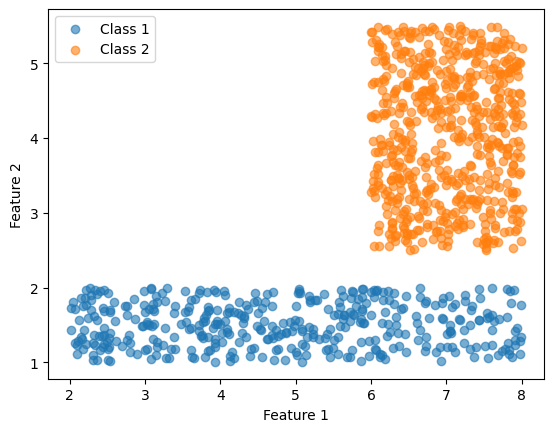

In [2235]:
plt.scatter(omega1[:,0], omega1[:,1], label='Class 1', alpha=0.6)
plt.scatter(omega2[:,0], omega2[:,1], label='Class 2', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

**Concatenate the classes into a single vector named X and the targets into another vector named y**

In [2236]:
X = np.vstack((omega1, omega2))
y = np.concatenate((omega1_labels, omega2_labels))

print(f"First 5 points of the first class:\n {X[0:5]}")
print(f"\nWith responces:\n {y[0:5]}")
print("\n##\n")
print(f"First 5 points of the second class:\n {X[400:405]}")
print(f"\nWith responces:\n {y[400:405]}")
print("\n##\n")
print(f"Length of first class: {omega1.shape[0]}")
print(f"Length of second class: {omega2.shape[0]}")
print(f"Length of the X matrix: {X.shape[0]}")

First 5 points of the first class:
 [[5.88448  1.688151]
 [3.603672 1.83087 ]
 [6.939188 1.59815 ]
 [5.623699 1.888298]
 [3.531013 1.677556]]

With responces:
 [0. 0. 0. 0. 0.]

##

First 5 points of the second class:
 [[7.935378 4.281635]
 [7.357359 5.40353 ]
 [7.027812 5.277239]
 [7.24973  5.108351]
 [6.205537 2.989395]]

With responces:
 [1. 1. 1. 1. 1.]

##

Length of first class: 400
Length of second class: 600
Length of the X matrix: 1000


As you can see, we have combined both classes into a single matrix. The length of the new matrix is 1000 (the sum of the lengths of each class). We have also generated a vector named y, which consists of the labels of each class. The length of this vector is also 1000. The first 400 elements of this vectors are 0 (the responces of the first class), while the remaining 600 elements are 1 (the responces of the second class)

We can also use the concatenated vector X to plot our data into the 2D space

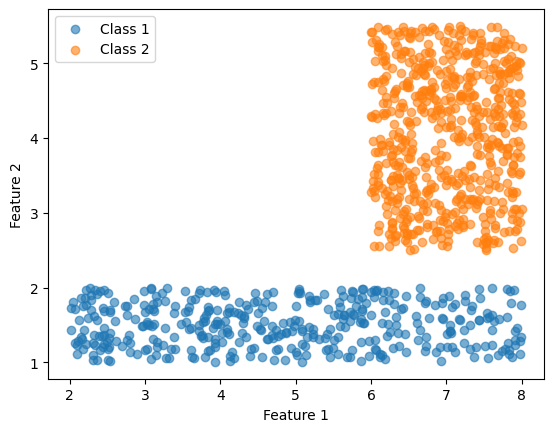

In [2237]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 1', alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 2', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# PART B: Bayesian Classification in 2D Space

## B1: Estimate $\mu$ and $\Sigma$ using Maximum Likelihood Estimation

The 2D Gaussian distribution is given by the formula:

$$
p(\underset{-}{x}) = \frac{1}{2\pi |\Sigma|^{1/2}} \exp \left( -\frac{1}{2} (
\underset{-}{x} - \underset{-}{\mu_i} ) \Sigma^{-1} (
\underset{-}{x} - \underset{-}{\mu_i} )^T \right)
$$

where:
- $\underset{-}{\mu_i}$  is the mean vector.
- $\Sigma$ is the covariance matrix.

The $\underset{-}{\mu_i}$ vector is unknown, and we need to compute it using the Maximum Likelihood Estimation Method.

Obviously, since $\underset{-}{\mu_i}$ is unknown, $p(\underset{-}{x})$ is also unknown and we can write the expression as $p(\underset{-}{x}; \underset{-}{\mu_i})$

Let also $X =$ {$\underset{-}{x_1}, \underset{-}{x_2}, ..., \underset{-}{x_N}$}

We have the following formula:

$$
p(X; \underset{-}{\mu_i}) = \prod p(\underset{-}{x_i}; \underset{-}{\mu_i})
$$

We can also define the log-likelihood function, given by the formula:

$$
L(\underset{-}{\mu_i}) = ln(\prod_{i=1}^N p(\underset{-}{x_i}; \underset{-}{\mu_i})) = \sum_{i=1}^N ln(p(\underset{-}{x_i}; \underset{-}{\mu_i}))
$$

Our goal is estimate the $\underset{-}{\mu_i}$ to maximize the log-likelihood function, or equivalently, find the derivative of $L(\underset{-}{\mu_i})$ with respect to $\underset{-}{\mu_i}$ and set it to zero. 

We have created an equation from which we can estimate the $\underset{-}{\mu_i}$. The same logic we will follow to estimate the $\Sigma$ too

By applying the formulas above into the 2D Gaussian, we get the following results:

$$
L(\underset{-}{\mu}) = - \frac{N}{2} ln(2\pi|\Sigma|) - \frac{1}{2}\sum_{i=1}^N 
(\underset{-}{x_i} - \underset{-}{\mu})^T \Sigma^{-1} (\underset{-}{x_i} - \underset{-}{\mu})
$$

$$
\frac{\partial L(\underset{-}{\mu})}{\partial \underset{-}{\mu}} = \sum_{i=1}^N \Sigma^{-1} (\underset{-}{x_i} - \underset{-}{\mu}) = 0
$$

Or equivalently:

$$
\mu_{ML} = \frac{1}{N} \sum_{i=1}^N \underset{-}{x_i}
$$

In [2238]:
# Estimate the mean value using the formula that the ML found
# Mean Value of the first class

mean_1_x = sum(omega1[:, 0]) / N1
mean_1_y = sum(omega1[:, 1]) / N1

mean1_ml = np.array([mean_1_x, mean_1_y])
print(f"Mean Value of the first class: {mean1_ml}")

# Mean Value of the second class

mean_2_x = sum(omega2[:, 0]) / N2
mean_2_y = sum(omega2[:, 1]) / N2

mean2_ml = np.array([mean_2_x, mean_2_y])
print(f"Mean Value of the second class: {mean2_ml}")

print("\n##\n")
print("Just for Verification")
print(f"Mean of Omega 1: {np.mean(omega1, axis=0)}")
print(f"Mean of Omega 2: {np.mean(omega2, axis=0)}")

Mean Value of the first class: [4.806693 1.507918]
Mean Value of the second class: [7.00605  4.052286]

##

Just for Verification
Mean of Omega 1: [4.806693 1.507918]
Mean of Omega 2: [7.00605  4.052286]


Now we need to compute the covariance matrix $\Sigma$ by following the same logic



The result of the log-likelihood function for the covariance matrix, is:

$$
L(\Sigma) = -  ln(2\pi) - \frac{N}{2} ln(\Sigma) - \frac{1}{2\Sigma} \sum_{i=1}^N (\underset{-}{x_i} - \underset{-}{\mu}) (\underset{-}{x_i} - \underset{-}{\mu})^T
$$

$$
\frac{\partial L (\Sigma)}{\partial \Sigma} = - \frac{N}{2\Sigma} + \frac{1}{2\Sigma^2} \sum_{i=1}^N (\underset{-}{x_i} - \underset{-}{\mu}) 
(\underset{-}{x_i} - \underset{-}{\mu})^T = 0
$$

Or, equivalently:

$$
\Sigma_{ML} = \frac{1}{N} \sum_{i=1}^N (\underset{-}{x_i} - \underset{-}{\mu}) (\underset{-}{x_i} - \underset{-}{\mu})^T
$$

So, we just need to compute the variance of each class, and then represent them in the Covariance Matrix format 

In [2239]:
# Estimate the covariance matrix using the formula that the ML found

# Covariance Matrix of the first class
cov1 = 0
for i in range(N1):
    deviation = omega1[i, :].reshape(2, 1) - mean1_ml.reshape(2, 1)
    prod = deviation @ deviation.T
    cov1 = cov1 + prod

cov_matrix1 = cov1/N1

# Covariance Matrix of the second class
cov2 = 0
for i in range(N2):
    deviation = omega2[i, :].reshape(2, 1) - mean2_ml.reshape(2, 1)
    prod = deviation @ deviation.T
    cov2 = cov2 + prod

cov_matrix2 = cov2/N2

print("Covariance Matrix of the first class:")
print(cov_matrix1)
print("\n##\n")
print("Covariance Matrix of the second class:")
print(cov_matrix2)

print("\n##\n")

print("Covariance Matrix of the first class just for verification:")
np1_cov_matrix = np.cov(omega1.T, bias=True)
print(np1_cov_matrix)

print("\n##\n")

print("Covariance Matrix of the second class just for verification:")
np2_cov_matrix = np.cov(omega2.T, bias=True)
print(np2_cov_matrix)

Covariance Matrix of the first class:
[[2.96191  0.002048]
 [0.002048 0.081731]]

##

Covariance Matrix of the second class:
[[0.344815 0.012791]
 [0.012791 0.753857]]

##

Covariance Matrix of the first class just for verification:
[[2.96191  0.002048]
 [0.002048 0.081731]]

##

Covariance Matrix of the second class just for verification:
[[0.344815 0.012791]
 [0.012791 0.753857]]


## B2: Classify Data using Euclidean Distance and Compute the Corresponding Error

Euclidean Distance Classifier: Assign $\underset{-}{x}$ -> $\omega_i$ when $|| \underset{-}{x} - \underset{-}{\mu_i} ||$ is smaller

In [2240]:
# We are going to use the X vector that we introduced to part A in this question, 
# which contains all points from these two classes

dist_from_mean1 = np.zeros(N)
dist_from_mean2 = np.zeros(N)

# Find the Euclidean distance of each point from the mean of the each class, and store it in the appropriate variable
for i in range(N):
    dist_from_mean1[i] = np.linalg.norm(X[i, :].reshape(2, 1) - mean1_ml.reshape(2, 1))
    dist_from_mean2[i] = np.linalg.norm(X[i, :].reshape(2, 1) - mean2_ml.reshape(2, 1))

Now that we have calculated the Euclidean Distance of each point from each mean, we will create a new target vector. This vector will contain 0 if a point is assigned to the first class, or 1, if it is assigned to the second class. A point will have the value 0 if it is closer to the $\mu_1$, or equivalently, if its Euclidean Distance from $\mu_1$ is smaller, and the value 1, if it is closer to the $\mu_2$. Then, we have to compute the classification error. All we have to do, is to compare the labelled vector **y** from part A with the new target vector, that is returned from create_target_vector function

In [2241]:
# Classify each point according to the L2 Distance from each mean
y_eu = create_target_vector(dist_from_mean1, dist_from_mean2)

# Compute the error by using this function which measures the wrongly classified points
err_eu = measure_error(y, y_eu)    

# Print the number of errors and the corresponding percantance
print(f"There are {err_eu} wrongly classified points, at a rate of {(err_eu/N)*100}%")


There are 36 wrongly classified points, at a rate of 3.5999999999999996%


And the new plot will look like this:

In [2242]:
# Just for convinience
mean_mat = np.vstack((mean1_ml, mean2_ml))

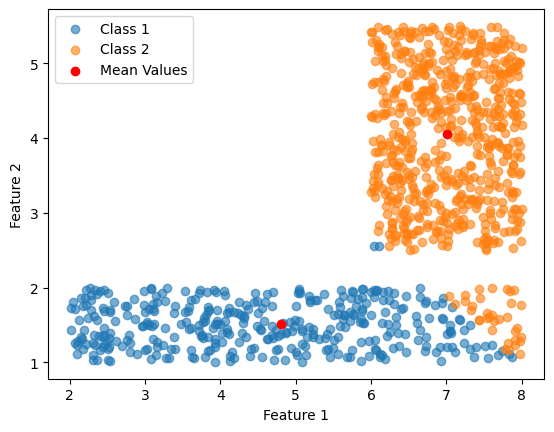

In [2243]:
plt.scatter(X[y_eu == 0][:, 0], X[y_eu == 0][:, 1], label='Class 1', alpha=0.6)
plt.scatter(X[y_eu == 1][:, 0], X[y_eu == 1][:, 1], label='Class 2', alpha=0.6)
plt.scatter(mean_mat[:, 0], mean_mat[:, 1], label='Mean Values', c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## B3: Classify Data using Mahalanobis Distance and Compute the Corresponding Error

The Mahalanobis Distance is given from the following formula:

$$
d_M = \sqrt{ (\underset{-}{x} - \underset{-}{\mu_i} )^T \Sigma^{-1} (
\underset{-}{x} - \underset{-}{\mu_i})}
$$

So, the corresponding classifier, assigns $\underset{-}{x}$ -> $\omega_i$ when $d_M$ is smaller. That means that the points that are closer to the first mean will be assigned to the first class, and the points that are closer to the second mean will be assigned to the second class. But now the distance will be the Mahalanobis Distance, instead of the Euclidean Distance

The first step that we have to do is to compute the weighted average of the two covariance matrices. The $\omega_1$ class has 400 points out of 1000, while $\omega_2$ class has 600 points. That means, that the weight for $\omega_1$ will be 400/1000 = 0.4, while for $\omega_2$ will be 600/1000 = 0.6

In [2244]:
# Find the weighted average of the two covariance matrices

w1 = N1/N
w2 = N2/N

weighted_cov_matrix = w1 * cov_matrix1 + w2 * cov_matrix2
inv_weighted_cov_matrix = np.linalg.inv(weighted_cov_matrix)
print(f"The Weighted Average of the two Covariance Matrices will be: \n{weighted_cov_matrix}")
print("\n##\n")
print(f"And its Inverse: \n{inv_weighted_cov_matrix}")


The Weighted Average of the two Covariance Matrices will be: 
[[1.391653 0.008494]
 [0.008494 0.485006]]

##

And its Inverse: 
[[ 0.718647 -0.012586]
 [-0.012586  2.062048]]


From now on, we will follow the same procedure, but with the Mahalanobis Distance

In [2245]:
# Compute the Mahalanobis Distance 

mah_dist_from_mean1 = np.zeros(N)
mah_dist_from_mean2 = np.zeros(N)

# Find the Mahalanobis distance of each point from the mean of the first class
for i in range(N):
    deviation = X[i, :].reshape(2, 1) - mean1_ml.reshape(2, 1)
    mah_dist_from_mean1[i] = np.sqrt(deviation.T @ inv_weighted_cov_matrix @ deviation)

# Find the Mahalanobis distance of each point from the mean of the second class
for i in range(N):
    deviation = X[i, :].reshape(2, 1) - mean2_ml.reshape(2, 1)
    mah_dist_from_mean2[i] = np.sqrt(deviation.T @ inv_weighted_cov_matrix @ deviation)

In [2246]:
# Classify each point according to the Mahalanobis Distance from each mean, and print the total errors of the classifier
y_mah = create_target_vector(mah_dist_from_mean1, mah_dist_from_mean2)
err_mah = measure_error(y, y_mah)
print(f"There are {err_mah} wrongly classified points, at a rate of {(err_mah/N)*100}%")

There are 8 wrongly classified points, at a rate of 0.8%


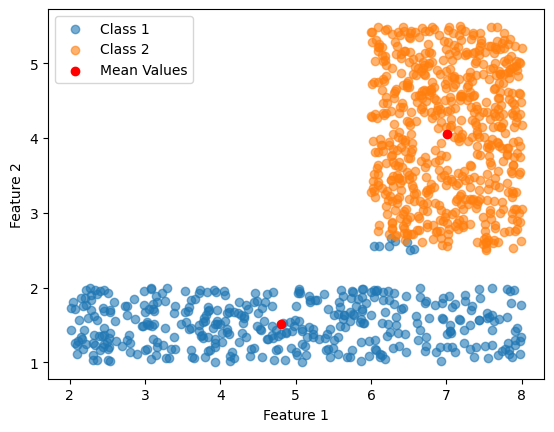

In [2247]:
plt.scatter(X[y_mah == 0][:, 0], X[y_mah == 0][:, 1], label='Class 1', alpha=0.6)
plt.scatter(X[y_mah == 1][:, 0], X[y_mah == 1][:, 1], label='Class 2', alpha=0.6)
plt.scatter(mean_mat[:, 0], mean_mat[:, 1], label='Mean Values', c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## B4: Classify Data using Bayesian Classifier and Compute the Corresponding Error

The Bayes Classification Rule tell us that:

- If $P(\omega_1|\underset{-}{x}) > P(\omega_2|\underset{-}{x})$, assign $\underset{-}{x}$ to $\omega_1$
- If $P(\omega_1|\underset{-}{x}) < P(\omega_2|\underset{-}{x})$, assign $\underset{-}{x}$ to $\omega_2$

By using this rule and having in mind the Bayes Theory:

$$
P(\omega_i|\underset{-}{x}) = \frac{p(\underset{-}{x}|\omega_i) * P(\omega_i)}{p(\underset{-}{x})}
$$

We have the following, equivalent, rule:

$$
p(\underset{-}{x}|\omega_1) * P(\omega_1) (><) p(\underset{-}{x}|\omega_2) * P(\omega_2)
$$

Obviouslu, $P(\omega_1)$ = 400/1000 = 0.4 and $P(\omega_2)$ = 600/1000 = 0.6, so we only need to compute $p(\underset{-}{x}|\omega_1)$ and $p(\underset{-}{x}|\omega_2)$

Again, we will follow the same steps in this question, but we will use the Bayesian Classifier to assign each point to one class. The basic difference in this question with the questions above, is that this is a probabilistic model, while the previous two models were using proximity metrics to assign each point to one class. 

In [2248]:
# Compute the class conditional pdfs. It is known that they are following a Gaussian Distribution
omega1_poss = np.zeros(N)
omega2_poss = np.zeros(N)

det_cov1 = np.linalg.det(cov_matrix1)
det_cov2 = np.linalg.det(cov_matrix2)

for i in range(N):
    deviation1 = X[i, :].reshape(2, 1) - mean1_ml.reshape(2, 1)
    deviation2 = X[i, :].reshape(2, 1) - mean2_ml.reshape(2, 1)

    exponent1 = -(deviation1.T @ np.linalg.inv(cov_matrix1) @ deviation1) / 2
    exponent2 = -(deviation2.T @ np.linalg.inv(cov_matrix2) @ deviation2) / 2

    omega1_poss[i] = np.exp(exponent1) / (2 * np.pi * np.sqrt(det_cov1))
    omega2_poss[i] = np.exp(exponent2) / (2 * np.pi * np.sqrt(det_cov2))

In [2249]:
# Classify the vector to the corresponding class according to the Bayes Classification Rule

p_omega1 = N1/N
p_omega2 = N2/N

omega1_bayes = p_omega1 * omega1_poss
omega2_bayes = p_omega2 * omega2_poss

y_bayes = create_target_vector(omega2_bayes, omega1_bayes)
err_bayes = measure_error(y, y_bayes)
print(f"There are {err_bayes} wrongly classified points, at a rate of {(err_bayes/N)*100}%")


There are 0 wrongly classified points, at a rate of 0.0%


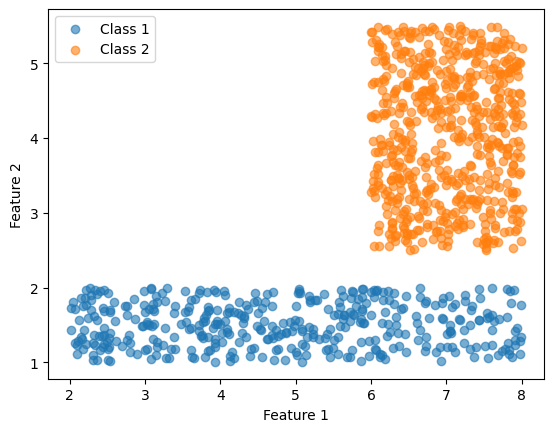

In [2250]:
plt.scatter(X[y_bayes == 0][:, 0], X[y_bayes == 0][:, 1], label='Class 1', alpha=0.6)
plt.scatter(X[y_bayes == 1][:, 0], X[y_bayes == 1][:, 1], label='Class 2', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# PART C: Dimensionality Reduction Techniques

## C1: PRINCIPAL COMPONENT ANALYSIS - PCA

In this subquetion, we have to perform feature selection by using the PCA technique. In general, this technique consists of 5 steps

i) **Data Standardization**: in our example, the range of the features of the omega 1 class is larger and it will lead to biased results. That's why, we need to standardize the data before applying the PCA algorithm. This standardization can be done by substracting the mean of a vector and then deviding by its standard deviation

In [2251]:
# Standarize the combined vector X with the mutual mean of the two classes
std_dev = np.std(X, axis=0)
mutual_mean = np.mean(X, axis=0)

X_std = (X - mutual_mean) / std_dev
print(f"The first 5 entries of the scaled vector: \n{X_std[0:5]}")

The first 5 entries of the scaled vector: 
[[-0.151362 -0.942956]
 [-1.578939 -0.843001]
 [ 0.508789 -1.005989]
 [-0.314587 -0.802781]
 [-1.624417 -0.950376]]


In [2252]:
# Verify the Standardization using StandardScaler function
scaler = StandardScaler()
verify_std = scaler.fit_transform(X)
print(f"Just for Verification:\n{verify_std[0:5]}")

Just for Verification:
[[-0.151362 -0.942956]
 [-1.578939 -0.843001]
 [ 0.508789 -1.005989]
 [-0.314587 -0.802781]
 [-1.624417 -0.950376]]


ii) Compute the **Covariance Matrix**

In [2253]:
# Unsupervised Learning => We will not need any labels vector
# Compute directly the covariance matrix
cov_matrix_pca = np.cov(X_std.T)

print(f"Covariance Matrix of vector X: \n{cov_matrix_pca}")

Covariance Matrix of vector X: 
[[1.001001 0.59305 ]
 [0.59305  1.001001]]


iii) Find the **Eigenvalues** and **Eigenvectors** of the Covariance Matrix

In [2254]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix_pca)
print(f"Eigenvalues of the Covariance Matrix: \n{eigenvalues}")
print("\n##\n")
print(f"And the Corresponding Eigenvectors: \n{eigenvectors}")

Eigenvalues of the Covariance Matrix: 
[1.594051 0.407951]

##

And the Corresponding Eigenvectors: 
[[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]


iv) Keep only the heighest eigenvalue and its corresponding eigenvector, and **Project the Data** in this eigenvector

In [2255]:
e_value = eigenvalues[0]
e_vector = eigenvectors[:, 0]
projected_data = X_std.dot(e_vector)

print(f"First 5 points projected on the line that the eigenvector define:\n{projected_data[0:5]}")

First 5 points projected on the line that the eigenvector define:
[-0.773799 -1.71257  -0.351574 -0.790098 -1.820654]


v) **Plot the Data** in the 1D plane that the PCA Analysis found

In [2256]:
# Compute the means after the standardization, and the projected means, before plotting
mean1_std = np.mean(X_std[0:N1], axis=0)
mean2_std = np.mean(X_std[N1+1:N], axis=0)
mean_std = np.vstack((mean1_std, mean2_std))

projected_means = mean_std.dot(e_vector)
print(f"Means projected on the line that the eigenvalues define:\n{projected_means}")

Means projected on the line that the eigenvalues define:
[-1.340067  0.892502]


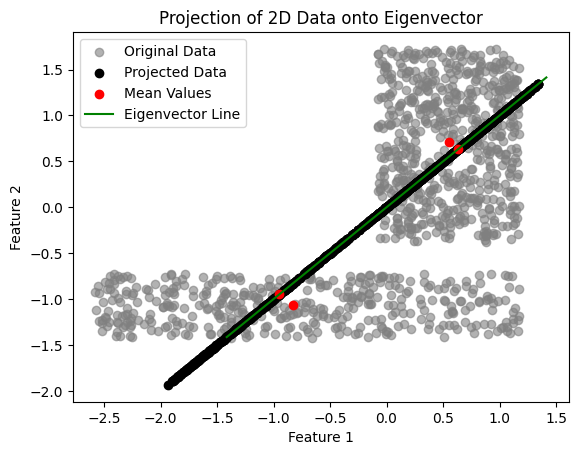

In [2257]:
# Plot the original 2D data with gray colour because they are still unlabelled
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.6, label='Original Data', color='gray')
plt.scatter(mean1_std[0], mean1_std[1], c='red')
plt.scatter(mean2_std[0], mean2_std[1], c='red')

# Convert the 1D projections back to 2D points along the eigenvector, using the outer product
projected_points = np.outer(projected_data, e_vector)
projected_mean_points = np.outer(projected_means, e_vector)

# Plot the projected 1D data with black colour along the line that the eigenvector defines/
plt.scatter(projected_points[:, 0], projected_points[:, 1], label='Projected Data', color='black')
plt.scatter(projected_mean_points[:, 0], projected_mean_points[:, 1], label='Mean Values', color='red')

# Plot the line defined by the eigenvector
origin = np.mean(X_std, axis=0)
line_x = np.array([origin[0] - 2*e_vector[0], origin[0] + 2*e_vector[0]])
line_y = np.array([origin[1] - 2*e_vector[1], origin[1] + 2*e_vector[1]])
plt.plot(line_x, line_y, label='Eigenvector Line', color='green')

# Create the plot
plt.title('Projection of 2D Data onto Eigenvector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


## C2: Classify the Points to 1D plane that PCA defined using Euclidean Distance Classifier

In the previous question, we managed to project the points into a 1D plane (the line defined by the eigenvector), but we didn't assigned any label to the projected points. In this question, we will classify these points using the Euclidean Distance Classifier

Reminder from B2: Euclidean Distance Classifier: Assign $\underset{-}{x}$ -> $\omega_i$ when $|| \underset{-}{x} - \underset{-}{\mu_i} ||$ is smaller

In [2258]:
# Initialize the distance vectors
dist_from_mean1_pca = np.zeros(N)
dist_from_mean2_pca = np.zeros(N)

# Find the L2 distance from each point from each mean
for i in range(N):
    dist_from_mean1_pca[i] = np.abs(projected_data[i] - projected_means[0])
    dist_from_mean2_pca[i] = np.abs(projected_data[i] - projected_means[1])

In [2259]:
# Create the new target vector and compute the error
y_pca = create_target_vector(dist_from_mean1_pca, dist_from_mean2_pca)
err_pca = measure_error(y, y_pca)
print(f"There are {err_pca} wrongly classified points, at a rate of {(err_pca/N)*100}%")


There are 41 wrongly classified points, at a rate of 4.1000000000000005%


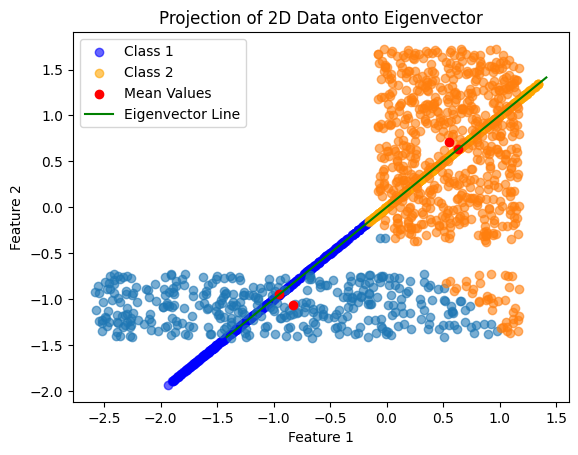

In [2260]:
# Convert the 1D projections back to 2D points along the eigenvector, using the outer product
projected_points = np.outer(projected_data, e_vector)
projected_mean_points = np.outer(projected_means, e_vector)

# Plot the projected 1D data with black colour along the line that the eigenvector defines
plt.scatter(projected_points[y_pca == 0][:, 0], projected_points[y_pca == 0][:, 1], label='Class 1', alpha=0.6, color='blue')
plt.scatter(projected_points[y_pca == 1][:, 0], projected_points[y_pca == 1][:, 1], label='Class 2', alpha=0.6, color='orange')

# Plot the labelled 2D data
plt.scatter(X_std[y_pca == 0][:, 0], X_std[y_pca == 0][:, 1], alpha=0.6)
plt.scatter(X_std[y_pca == 1][:, 0], X_std[y_pca == 1][:, 1], alpha=0.6)

# Insert the Mean Values of each class and the Projected Mean Values in the new 1D space
plt.scatter(projected_mean_points[:, 0], projected_mean_points[:, 1], label='Mean Values', color='red')
plt.scatter(mean1_std[0], mean1_std[1], c='red')
plt.scatter(mean2_std[0], mean2_std[1], c='red')

# Plot the line defined by the eigenvector
origin = np.mean(X_std, axis=0)
line_x = np.array([origin[0] - 2*e_vector[0], origin[0] + 2*e_vector[0]])
line_y = np.array([origin[1] - 2*e_vector[1], origin[1] + 2*e_vector[1]])
plt.plot(line_x, line_y, label='Eigenvector Line', color='green')

# Create the plot
plt.title('Projection of 2D Data onto Eigenvector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## C3: Linear Discriminant Analysis - LDA

Now, we have to perform an LDA analysis instead of PCA for feature selection. In contrast to PCA, LDA is a supervised technique, that means that we will have both data and its labels during the analysis. LDA Analysis consists of the following steps

i) Compute the **Within-Class Scatter Matrix**

The formula of Within-Class Scatter Matrix is:

$$
S_W = \sum_C S_C
$$

where

$$
S_C = \sum_{i\in C} (x_i - \underset{-}{\mu_c})(x_i - \underset{-}{\mu_c})^T
$$

and C stands for Class

The Within-Class Scatter Matrix measures how compact a class is, or equivalently, how close a point of a class is in comparison with each point inside a specific class. Obviously, the goal of LDA is to minimize this Scatter Matrix. The smaller the distance from one point to each other point, the more compact the class will be. That's why LDA is a supervised technique, we need to know in advance the classes to compute this scatter matrix.

In [2261]:
# Compute the sc1 and sc2 matrices first, and then, sum them to get sw

# Compute sc1, the scatter matrix of the first class
sc1 = 0

for i in range(N1):
    deviation = omega1[i, :].reshape(2, 1) - mean1_ml.reshape(2, 1)
    prod = deviation @ deviation.T
    sc1 = sc1 + prod
    
sc1 = sc1/N1
    
# Compute sc2, the scatter matrix of the second class
sc2 = 0
for i in range(N2):
    deviation = omega2[i, :].reshape(2, 1) - mean2_ml.reshape(2, 1)
    prod = deviation @ deviation.T
    sc2 = sc2 + prod
    
sc2 = sc2/N2

# Compute sw, the sum of the above two scatter matrices    
sw = sc1 + sc2

print(f"The Within-Class Scatter Matrix for the first class is: \n{sc1}")
print("\n##\n")
print(f"The Within-Class Scatter Matrix for the second class is: \n{sc2}")
print("\n##\n")

np.set_printoptions(precision=6, suppress=True)
print(f"The Within-Class Scatter Matrix for both classes is: \n{sw}")

The Within-Class Scatter Matrix for the first class is: 
[[2.96191  0.002048]
 [0.002048 0.081731]]

##

The Within-Class Scatter Matrix for the second class is: 
[[0.344815 0.012791]
 [0.012791 0.753857]]

##

The Within-Class Scatter Matrix for both classes is: 
[[3.306725 0.01484 ]
 [0.01484  0.835588]]


ii) Compute the **Between-Class Scatter Matrix**

The formula for the Between-Class Scatter Matrix is:

$$
S_B = \sum_C n_C (\underset{-}{\mu_c} - \underset{-}{x})(\underset{-}{\mu_c} - \underset{-}{x})^T
$$

or equivalently:

$$
S_B = \sum_{k=1}^{K} n_C (\underset{-}{\mu_k} - \mu)(\underset{-}{\mu_k} - \mu)^T
$$

where

- C: is the number of classes
- n_C is the number of feature in each class
- $\underset{-}{x}$ is the concatenated feature vector
- $\underset{-}{\mu_c}$ and $\underset{-}{\mu_k}$ are the means of each class
- $\mu$ is the total mean

In comparison with Within-Class Scatter Matrix, this one substracts the mean vector of each class from the global mean. The Between-Class Scatter Matrix shows us how well-seperated the classes are. Usually, larger Between-Class Scatter Matrices give us more accurate classification results, because the classes are more distinct. So, our goal is to maximize the Between-Class Scatter Matrix

In [2262]:
# Compute the total mean of the 2 classes
total_mean = np.mean(X, axis=0)

# Measure the scatter matrix of each class seperately
substr1 = mean1_ml.reshape(2, 1) - total_mean.reshape(2, 1)
substr2 = mean2_ml.reshape(2, 1) - total_mean.reshape(2, 1)
sb1 = N1*(substr1 @ substr1.T)
sb2 = N2*(substr2 @ substr2.T)

# Add the results for the mutual scatter matrix
sb = sb1 + sb2

print(f"The Between-Class Scatter Matrix for the first class is:\n{sb1}")
print("\n##\n")
print(f"The Between-Class Scatter Matrix for the second class is:\n{sb2}")
print("\n##\n")
print(f"The Between-Class Scatter Matrix for both classes is:\n{sb}")

The Between-Class Scatter Matrix for the first class is:
[[696.552938 805.820487]
 [805.820487 932.228725]]

##

The Between-Class Scatter Matrix for the second class is:
[[464.368625 537.213658]
 [537.213658 621.485817]]

##

The Between-Class Scatter Matrix for both classes is:
[[1160.921563 1343.034145]
 [1343.034145 1553.714542]]


iii) **Compute the matrix $S_W^{-1}S_B$** and find its **Eigenvalues** and **Eigenvectors**

In [2263]:
inv_sw = np.linalg.inv(sw)
combined_matrix = inv_sw @ sb
print(combined_matrix)

[[ 343.893346  397.839544]
 [1601.18553  1852.361871]]


In [2264]:
# Now we have to solve an eigenvalue-eigenvector problem
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(combined_matrix)
print(f"Eigenvalues of the Combined Matrix: \n{eigenvalues_lda}")
print("\n##\n")
print(f"And the Corresponding Eigenvectors: \n{eigenvectors_lda}")


Eigenvalues of the Combined Matrix: 
[   0.       2196.255217]

##

And the Corresponding Eigenvectors: 
[[-0.756536 -0.209986]
 [ 0.653952 -0.977704]]


iv) Keep only the heighest eigenvalue and its corresponding eigenvector, and **Project the Data** in this eigenvector

In [2265]:
e_value_lda = eigenvalues_lda[1]
e_vector_lda = eigenvectors_lda[:, 1]
normalize_e_vector = e_vector_lda / np.linalg.norm(e_vector_lda)

projected_data_lda = X.dot(e_vector_lda)

print(f"First 5 points projected on the line that the eigenvector define:\n{projected_data_lda[0:5]}")


First 5 points projected on the line that the eigenvector define:
[-2.886169 -2.546769 -3.019649 -3.027093 -2.381616]


v) **Plot the Data** in the 1D plane that the LDA Analysis found

In [2266]:
# Compute the means after the standardization, and the projected means, before plotting
mean1_lda = np.mean(X[0:N1], axis=0)
mean2_lda = np.mean(X[N1+1:N], axis=0)
mean_lda = np.vstack((mean1_lda, mean2_lda))

projected_means_lda = mean_lda.dot(e_vector_lda)
print(f"Means projected on the line that the eigenvalues define:\n{projected_means_lda}")

Means projected on the line that the eigenvalues define:
[-2.483635 -5.432409]


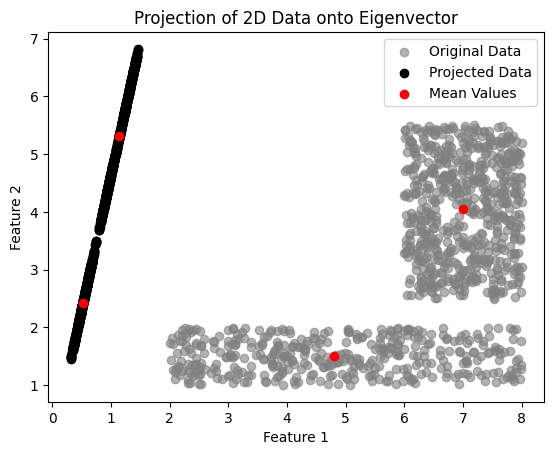

In [2267]:
# Plot the original 2D data with gray colour because they are still unlabelled
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, label='Original Data', color='gray')
plt.scatter(mean1_ml[0], mean1_ml[1], c='red')
plt.scatter(mean2_ml[0], mean2_ml[1], c='red')

# Convert the 1D projections back to 2D points along the eigenvector, using the outer product
projected_points_lda = np.outer(projected_data_lda, normalize_e_vector)
projected_mean_points_lda = np.outer(projected_means_lda, normalize_e_vector)

# Plot the projected 1D data with black colour along the line that the eigenvector defines/
plt.scatter(projected_points_lda[:, 0], projected_points_lda[:, 1], label='Projected Data', color='black')
plt.scatter(projected_mean_points_lda[:, 0], projected_mean_points_lda[:, 1], label='Mean Values', color='red')

# Plot the line defined by the eigenvector
#origin = np.mean(X, axis=0)
#line_x = np.array([origin[0] - 2*normalize_e_vector[0], origin[0] + 2*normalize_e_vector[0]])
#line_y = np.array([origin[1] - 2*normalize_e_vector[1], origin[1] + 2*normalize_e_vector[1]])
#plt.plot(line_x, line_y, label='Eigenvector Line', color='green')

# Create the plot
plt.title('Projection of 2D Data onto Eigenvector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## C4: Classify the Points to 1D plane that LDA defined using Euclidean Distance Classifier

The steps in this subquestion are the same with the C2 subquestion, but in LDA. We just have to classify the points according to L2 classifier

In [2268]:
# Initialize the distance vectors
dist_from_mean1_lda = np.zeros(N)
dist_from_mean2_lda = np.zeros(N)

# Find the L2 distance from each point from each mean
for i in range(N):
    dist_from_mean1_lda[i] = np.abs(projected_data_lda[i] - projected_means_lda[0])
    dist_from_mean2_lda[i] = np.abs(projected_data_lda[i] - projected_means_lda[1])

In [2269]:
# Create the new target vector and compute the corresponding error
y_lda = create_target_vector(dist_from_mean1_lda, dist_from_mean2_lda)
err_lda = measure_error(y, y_lda)        
print(f"There are {err_lda} wrongly classified points, at a rate of {(err_lda/N)*100}%")

There are 10 wrongly classified points, at a rate of 1.0%


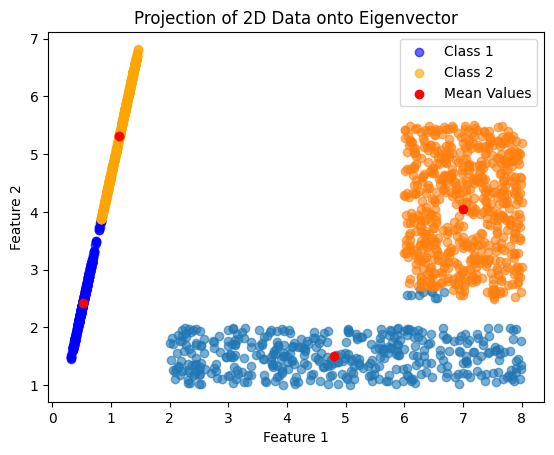

In [2270]:
# Convert the 1D projections back to 2D points along the eigenvector, using the outer product
projected_points_lda = np.outer(projected_data_lda, normalize_e_vector)
projected_mean_points_lda = np.outer(projected_means_lda, normalize_e_vector)

# Plot the projected 1D data with black colour along the line that the eigenvector defines
plt.scatter(projected_points_lda[y_lda == 0][:, 0], projected_points_lda[y_lda == 0][:, 1], label='Class 1', alpha=0.6, color='blue')
plt.scatter(projected_points_lda[y_lda == 1][:, 0], projected_points_lda[y_lda == 1][:, 1], label='Class 2', alpha=0.6, color='orange')

# Plot the labelled 2D data
plt.scatter(X[y_lda == 0][:, 0], X[y_lda == 0][:, 1], alpha=0.6)
plt.scatter(X[y_lda == 1][:, 0], X[y_lda == 1][:, 1], alpha=0.6)

# Insert the Mean Values of each class and the Projected Mean Values in the new 1D space
plt.scatter(projected_mean_points_lda[:, 0], projected_mean_points_lda[:, 1], label='Mean Values', color='red')
plt.scatter(mean1_lda[0], mean1_lda[1], c='red')
plt.scatter(mean2_lda[0], mean2_lda[1], c='red')

# Plot the line defined by the eigenvector
#origin = np.mean(X, axis=0)
#line_x = np.array([origin[0] - 2*normalize_e_vector[0], origin[0] + 2*normalize_e_vector[0]])
#line_y = np.array([origin[1] - 2*normalize_e_vector[1], origin[1] + 2*normalize_e_vector[1]])
#plt.plot(line_x, line_y, label='Eigenvector Line', color='green')

# Create the plot
plt.title('Projection of 2D Data onto Eigenvector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# PART D: Linear Classification with Cost Functions

## D1: Linear Classification using Least Squares

To use the Least Square Method, we need to give a label of +1 to the $\omega_1$ class and a label of -1 to the $\omega_2$ class

In [2271]:
omega1_new_labels = np.ones(N1)
omega2_new_labels = -1*np.ones(N2)
new_y = np.concatenate((omega1_new_labels, omega2_new_labels))

And we also need to extend the feature vector X

In [2272]:
X_ext = np.hstack((X, np.ones((N, 1))))
print(X_ext[0:5])

[[5.88448  1.688151 1.      ]
 [3.603672 1.83087  1.      ]
 [6.939188 1.59815  1.      ]
 [5.623699 1.888298 1.      ]
 [3.531013 1.677556 1.      ]]


The goal of the Least Squares Method is to compute the weights so that the cost function
$$
J(\underset{-}{w}) = E[y - \underset{-}{w^T}\underset{-}{x^2}]
$$
is minimized

By minimizing the cost function above, we can find the weights by the following formula:
$$
\underset{-}{w} = (X^TX)^{-1}X^T\underset{-}{y}
$$

So, we have to compute the components $X^TX$, $X^Ty$, and invert the first one

In [2273]:
xTx = X_ext.T @ X_ext
xTy = X_ext.T @ new_y
xTx_inv = np.linalg.inv(xTx)
print(f"First Term: \n{xTx}")
print("\n##\n")
print(f"Second Term: \n{xTy}")
print("\n##\n")
print(f"Inverse of the First Term: \n{xTx_inv}")

First Term: 
[[40084.215962 19942.04658   6126.307324]
 [19942.04658  11247.147827  3034.538974]
 [ 6126.307324  3034.538974  1000.      ]]

##

Second Term: 
[-2280.95304 -1828.20463  -200.     ]

##

Inverse of the First Term: 
[[ 0.000604 -0.0004   -0.002484]
 [-0.0004    0.000756  0.000158]
 [-0.002484  0.000158  0.015737]]


And now it's time to compute the $\underset{-}{w}$

In [2274]:
weights = xTx_inv @ xTy.reshape(3, 1)
print(f"Weights Found: \n{weights}")

Weights Found: 
[[-0.148531]
 [-0.500585]
 [ 2.228992]]


In [2275]:
# Just for convinience
slope1 = weights[0]
slope2 = weights[1]
intercept = weights[2]

Compute the Sum of Squares Error (SSE), which is given by the following formula:
$$
J(\underset{-}{w}) = \sum_{i=1}^N (y_i - \underset{-}{x_i^T}\underset{-}{w})^2
$$


In [2276]:
residuals = np.zeros(N)

for i in range(N):
    prod = slope1*X[i, 0] + slope2*X[i, 1] + intercept
    residuals[i] = np.power(new_y[i] - prod, 2)
    
sse = np.sum(residuals)
print(f"The Sum of Squares Error is: {sse}")

The Sum of Squares Error is: 191.83423282804134


We can also compute the Mean Squared Error (MSE), which is almost the same with the formula above, but it also devides with the number of points N (computes the mean instead of the residuals)

With MSE, we have the following error

In [2277]:
mse = sse/N
print(f"The Mean Squared Error is: {mse}")

The Mean Squared Error is: 0.19183423282804132


Create the plot with the line found above

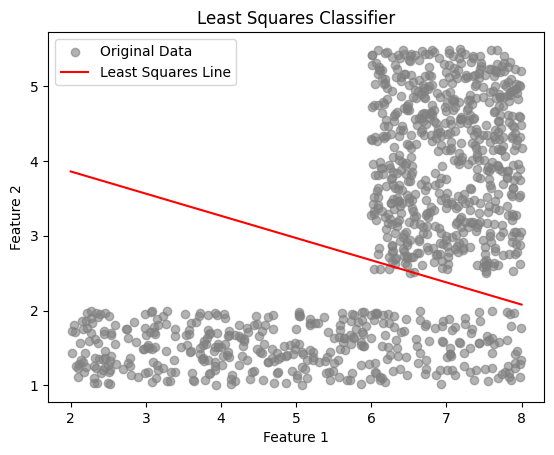

In [2278]:
# Plot the original 2D data with gray colour because they are still unlabelled
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, label='Original Data', color='gray')

x_values = np.linspace(2, 8, 100)
y_values = -1*(weights[0]*x_values + weights[2]) / weights[1]

plt.plot(x_values, y_values, label='Least Squares Line', color='red')

# Create the plot
plt.title('Least Squares Classifier')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


We can clearly see that this line classifies almost all the points correctly (it misses only a few). Let's assign them to classes

Assign each data to one class by the following constraints:

- if $\underset{-}{w}^T \underset{-}{x}$ > 0, assign $\underset{-}{x}$ -> $\omega_1$
- if $\underset{-}{w}^T \underset{-}{x}$ < 0, assign $\underset{-}{x}$ -> $\omega_2$ 

In [2279]:
y_ls = np.zeros(N)

# Compute the target vector
for i in range(N):
    dist = slope1*X[i, 0] + slope2*X[i, 1] + intercept 
    if dist < 0:
        y_ls[i] = -1
    else:
        y_ls[i] = 1 
        
# Print the Least Squares Classification Error
err_ls = measure_error(new_y, y_ls)
print(f"There are {err_ls} wrongly classified points, at a rate of {(err_ls/N)*100}%")
        

There are 4 wrongly classified points, at a rate of 0.4%


Create the plot after classification

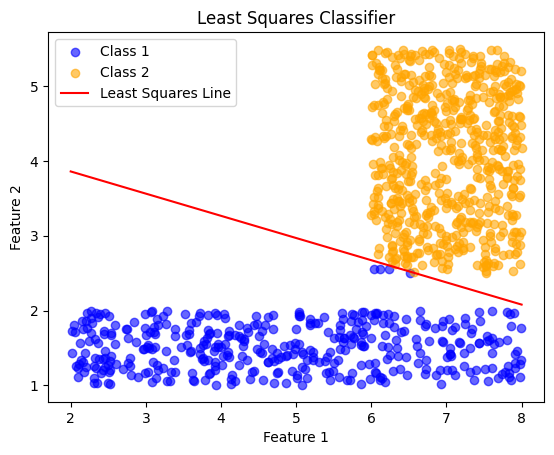

In [2280]:
# Plot the original 2D data with gray colour because they are still unlabelled
plt.scatter(X[y_ls == 1][:, 0], X[y_ls == 1][:, 1], alpha=0.6, label='Class 1', color='blue')
plt.scatter(X[y_ls == -1][:, 0], X[y_ls == -1][:, 1], alpha=0.6, label='Class 2', color='orange')

x_values = np.linspace(2, 8, 100)
y_values = -1*(weights[0]*x_values + weights[2]) / weights[1]

plt.plot(x_values, y_values, label='Least Squares Line', color='red')

# Create the plot
plt.title('Least Squares Classifier')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Observations

## Part B

As you can see from the results above, the Bayesian Classifier is always the best with 0 wrongly classificated points. The worst classifier amongst these 3 is Euclidean Distance Classifier with an error rate around 3-5%. That's because this classifiers is good only for spherical classes, because it measures the L2 distance from a mean of a class to every point without taking into account the covariance of the classes, and its performance is poor when it deals with data with weird shapes. On the other hand, Mahalanobis Distance Classifier takes into consideration the covariance of a class and deals better with non spherical classes. In our example, most of the times, this classifier has an error rate between 0.5-2%. Finally, the Bayesian Classifier is the best and, almost all the times, it has a 0 error rate. That's because our classes are well-seperated, and if we assign a Gaussian to each class, these won't have a large overlapping area and, almost always, it will classify our points 100% correctly. Below you can see in summary the error rate of each classifier.

In [2283]:
print("EUCLIDEAN CLASSIFIER")
print(f"There are {err_eu} wrongly classified points, at a rate of {(err_eu/N)*100}%")
print("\n##\n")
print("MAHALANOBIS CLASSIFIER")
print(f"There are {err_mah} wrongly classified points, at a rate of {(err_mah/N)*100}%")
print("\n##\n")
print("BAYES CLASSIFIER")
print(f"There are {err_bayes} wrongly classified points, at a rate of {(err_bayes/N)*100}%")

EUCLIDEAN CLASSIFIER
There are 36 wrongly classified points, at a rate of 3.5999999999999996%

##

MAHALANOBIS CLASSIFIER
There are 8 wrongly classified points, at a rate of 0.8%

##

BAYES CLASSIFIER
There are 0 wrongly classified points, at a rate of 0.0%


## Part C

Obviously, the line that LDA finds is much better than the one that PCA finds in our example. That's because PCA is suitable only for cases when our data are spread around a long and narrow hyperplane, with high variance, while in our example, as you can see, the gray points are spread around a shape that tends to be a cycle. That means that when we find the direction with the heighest variance, we are still having a considerable information loss, because that variance is not that much to "explain" the space fully. On the other hand, if we project the data on the line that LDA found, we will obtain better results. This can be seen from the error rate, where for LDA is not greater than 2%, while for PCA is usually 4-6% but sometimes can go up to 40-50% (kinda unstable in our example, because of the randomness of the points when we re-run the code). Furthermore, we can see in the LDA plot that we can seperate the classes using a linear classifier and get a model with 0% error. In our example we have used the Euclidean Distance Classifier to evaluate the PCA and LDA which is not the optimal one (but it is the simpliest one). Other classifiers like Mahalanobis Distance Classifier, SVM, and even more a linear perceptron with only 1 level may reach an accuracy of 100% in the LDA technique

In [2284]:
print("PCA ANALYSIS")
print(f"There are {err_pca} wrongly classified points, at a rate of {(err_pca/N)*100}%")
print("\n##\n")
print("LDA ANALYSIS")
print(f"There are {err_lda} wrongly classified points, at a rate of {(err_lda/N)*100}%")

PCA ANALYSIS
There are 41 wrongly classified points, at a rate of 4.1000000000000005%

##

LDA ANALYSIS
There are 10 wrongly classified points, at a rate of 1.0%
